<a href="https://colab.research.google.com/github/juanivazquez/SdT/blob/main/Granger%26Newbold%5B1973%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## # Rep. | **Spurious Regressions in Econometrics**
*Granger & Newbold (1973)*

### GEC0319 | JIVB | Time Series
- Replication N° **0**  
- Link: [here](https://www.sciencedirect.com/science/article/abs/pii/0304407674900347)

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

np.random.seed(238)

class CFG:
    data_folder = '/data/'
    img_dim1 = 25
    img_dim2 = 8
    style = 'https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pitayasmoothie-light.mplstyle'

plt.rcParams.update({'figure.figsize': (CFG.img_dim1,CFG.img_dim2)})
plt.style.use(CFG.style)

## Exp. N°0 : Level White Noise

In [6]:
t = 50
n_exp = 1000

exp_ls = []
pval_ls = []
r_sq_ls = []
dw_ls = []

for j in range(n_exp):
    x = np.random.normal(0, 1, t)
    y = np.random.normal(0, 1, t)

    experimento = pd.DataFrame({
        'obs': range(1, t+1),
        'x': x,
        'y': y
    })

    # Fit linear model y ~ x
    X = sm.add_constant(experimento['x'])  # Add constant term (intercept)
    model = sm.OLS(experimento['y'], X).fit()

    # Extract p-value and R-squared
    pval = round(model.pvalues[1], 3)  # p-value for x coefficient
    r_sq = round(model.rsquared, 3)

    # Calculate Durbin-Watson statistic
    dw = durbin_watson(model.resid)

    # Store results
    exp_ls.append(j+1)
    pval_ls.append(pval)
    r_sq_ls.append(r_sq)
    dw_ls.append(dw)

res_df = pd.DataFrame({
    'exp': exp_ls,
    'pvalues': pval_ls,
    'rsquared': r_sq_ls,
    'd_watson': dw_ls
})

res_df = res_df.sort_values(by='pvalues', ascending=False)

proportion_significant = sum(res_df['pvalues'] < 0.05) / n_exp

print(f"Proportion of significant p-values: {proportion_significant}")

<ipython-input-6-7665f2850681>:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = round(model.pvalues[1], 3)  # p-value for x coefficient
<ipython-input-6-7665f2850681>:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = round(model.pvalues[1], 3)  # p-value for x coefficient
<ipython-input-6-7665f2850681>:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = round(model.pvalues[1], 3)  # p-value for x coefficient
<ipy

Proportion of significant p-values: 0.039


<ipython-input-6-7665f2850681>:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = round(model.pvalues[1], 3)  # p-value for x coefficient
<ipython-input-6-7665f2850681>:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = round(model.pvalues[1], 3)  # p-value for x coefficient
<ipython-input-6-7665f2850681>:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = round(model.pvalues[1], 3)  # p-value for x coefficient
<ipy

In [7]:
print(f"Proportion of significant p-values: {proportion_significant}")

Proportion of significant p-values: 0.039


## Exp. N°1 : Random Walk Level

In [8]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

# Set random seed
np.random.seed(238)


In [9]:

# Define parameters
t = 50
n_exp = 100

# Initialize lists to store results
exp_ls = []
pval_ls = []
r_sq_ls = []
dw_ls = []

# Run the experiment 'n_exp' times
for j in range(n_exp):
    # Generate random walks for x and y
    x = np.cumsum(np.random.choice([-1, 1], size=t))
    y = np.cumsum(np.random.choice([-1, 1], size=t))

    # Create DataFrame
    experimento = pd.DataFrame({
        'obs': range(1, t+1),
        'x': x,
        'y': y
    })

    # Fit linear model y ~ x
    X = sm.add_constant(experimento['x'])  # Add constant term (intercept)
    model = sm.OLS(experimento['y'], X).fit()

    # Extract p-value and R-squared
    pval = round(model.pvalues[1], 3)  # p-value for x coefficient
    r_sq = round(model.rsquared, 3)

    # Calculate Durbin-Watson statistic
    dw = durbin_watson(model.resid)

    # Store results
    exp_ls.append(j+1)
    pval_ls.append(pval)
    r_sq_ls.append(r_sq)
    dw_ls.append(dw)

# Create DataFrame with results
rwl_df = pd.DataFrame({
    'exp': exp_ls,
    'pvalues': pval_ls,
    'rsquared': r_sq_ls,
    'd_watson': dw_ls
})

# Sort by p-value in descending order
rwl_df = rwl_df.sort_values(by='pvalues', ascending=False)

# Calculate the proportion of experiments with p-value < 0.05
proportion_significant = sum(rwl_df['pvalues'] < 0.05) / n_exp

print(f"Proportion of significant p-values: {proportion_significant}")


<ipython-input-9-17a75c379ea8>:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = round(model.pvalues[1], 3)  # p-value for x coefficient
<ipython-input-9-17a75c379ea8>:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = round(model.pvalues[1], 3)  # p-value for x coefficient
<ipython-input-9-17a75c379ea8>:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = round(model.pvalues[1], 3)  # p-value for x coefficient
<ipy

Proportion of significant p-values: 0.62


<ipython-input-9-17a75c379ea8>:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = round(model.pvalues[1], 3)  # p-value for x coefficient
<ipython-input-9-17a75c379ea8>:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = round(model.pvalues[1], 3)  # p-value for x coefficient
<ipython-input-9-17a75c379ea8>:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = round(model.pvalues[1], 3)  # p-value for x coefficient
<ipy

In [10]:
print(f"Proportion of significant p-values: {proportion_significant}")

Proportion of significant p-values: 0.62


## Exp. N°2 : Random Walk Change

In [11]:
# Define parameters
t = 50
n_exp = 100

# Initialize lists to store results
exp_ls = []
pval_ls = []
r_sq_ls = []
dw_ls = []

# Run the experiment 'n_exp' times
for j in range(n_exp):
    # Generate random walks for x_level and y_level
    x_level = np.cumsum(np.random.choice([-1, 1], size=t))
    y_level = np.cumsum(np.random.choice([-1, 1], size=t))

    # Compute differences (diff)
    x_diff = np.diff(x_level, prepend=np.nan)  # prepend NaN to keep same length
    y_diff = np.diff(y_level, prepend=np.nan)

    # Create DataFrame and drop missing values
    experimento = pd.DataFrame({
        'obs': range(1, t+1),
        'x_level': x_level,
        'y_level': y_level,
        'x': x_diff,
        'y': y_diff
    }).dropna()

    # Fit linear model y ~ x
    X = sm.add_constant(experimento['x'])  # Add constant term (intercept)
    model = sm.OLS(experimento['y'], X).fit()

    # Extract p-value and R-squared
    pval = round(model.pvalues[1], 3)  # p-value for x coefficient
    r_sq = round(model.rsquared, 3)

    # Calculate Durbin-Watson statistic
    dw = durbin_watson(model.resid)

    # Store results
    exp_ls.append(j+1)
    pval_ls.append(pval)
    r_sq_ls.append(r_sq)
    dw_ls.append(dw)

# Create DataFrame with results
rwc_df = pd.DataFrame({
    'exp': exp_ls,
    'pvalues': pval_ls,
    'rsquared': r_sq_ls,
    'd_watson': dw_ls
})

# Sort by p-value in descending order
rwc_df = rwc_df.sort_values(by='pvalues', ascending=False)

# Calculate the proportion of experiments with p-value < 0.05
proportion_significant = sum(rwc_df['pvalues'] < 0.05) / n_exp

print(f"Proportion of significant p-values: {proportion_significant}")


<ipython-input-11-b41c5a009c4b>:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = round(model.pvalues[1], 3)  # p-value for x coefficient
<ipython-input-11-b41c5a009c4b>:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = round(model.pvalues[1], 3)  # p-value for x coefficient
<ipython-input-11-b41c5a009c4b>:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = round(model.pvalues[1], 3)  # p-value for x coefficient
<

Proportion of significant p-values: 0.04


<ipython-input-11-b41c5a009c4b>:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = round(model.pvalues[1], 3)  # p-value for x coefficient
<ipython-input-11-b41c5a009c4b>:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = round(model.pvalues[1], 3)  # p-value for x coefficient
<ipython-input-11-b41c5a009c4b>:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = round(model.pvalues[1], 3)  # p-value for x coefficient
<

In [12]:
print(f"Proportion of significant p-values: {proportion_significant}")

Proportion of significant p-values: 0.04


# Compared Results Viz

In [15]:
rwl_df['level'] = 'Random Walk Level'
rwc_df['level'] = 'Random Walk Change'
cols = 'pvalues,rsquared,d_watson,level'.split(',')
df_combined = pd.concat([rwl_df[cols], rwc_df[cols]])

# Create a custom palette for the 'hue' levels
soft_blue = sns.color_palette("pastel")[0]
soft_green = sns.color_palette("pastel")[2]
custom_palette = {'Random Walk Level': soft_blue, 'Random Walk Change': soft_green}

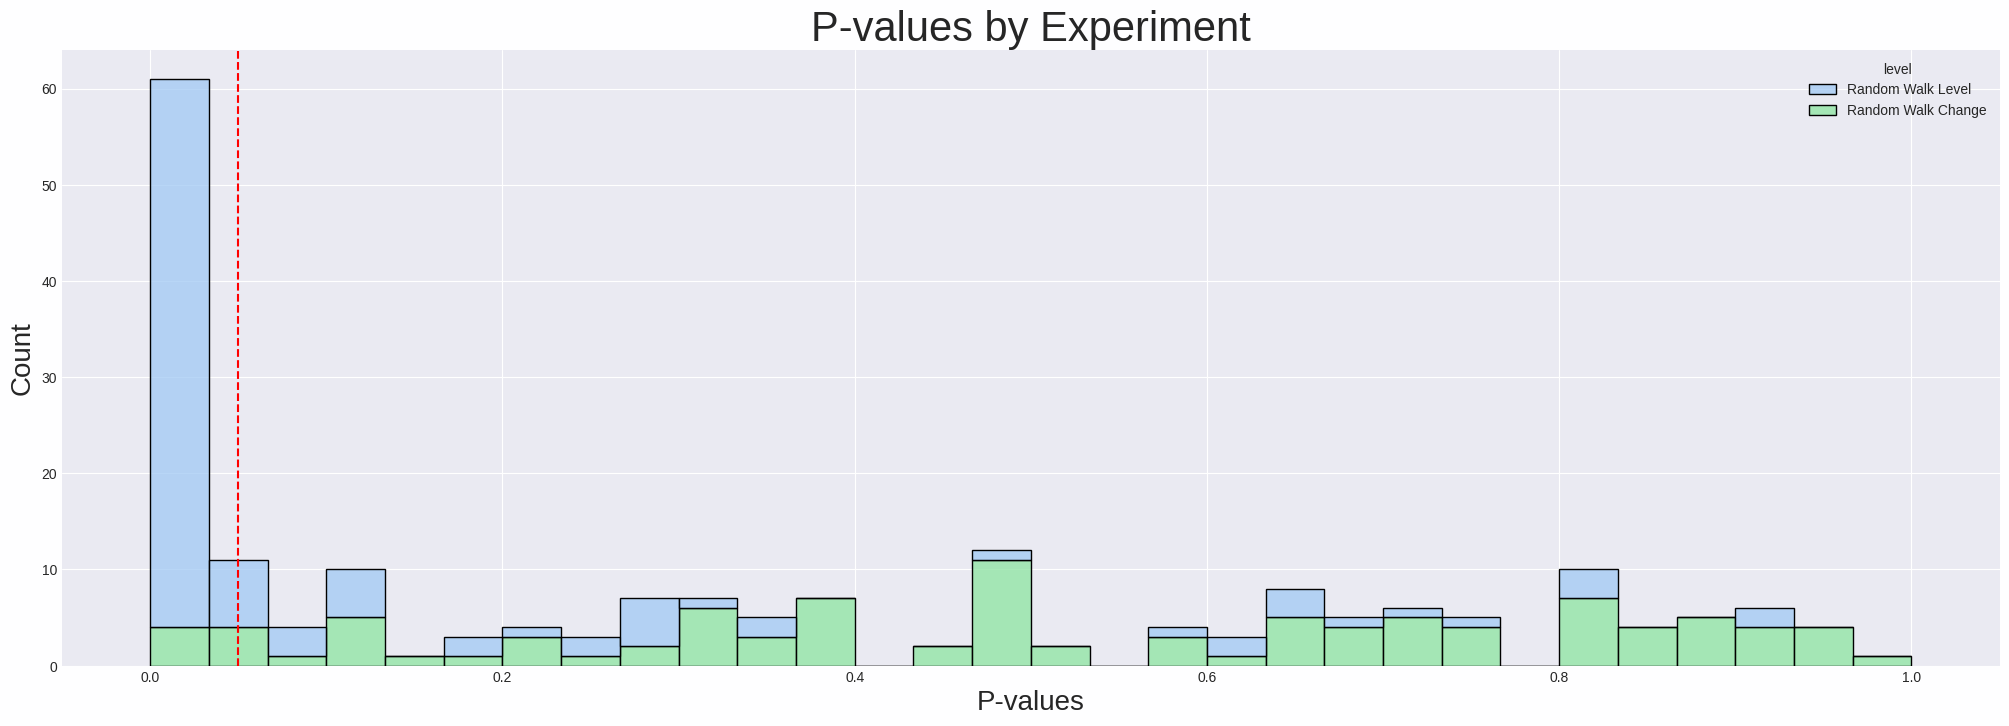

In [17]:
# plt.figure(figsize=(10, 6))
sns.histplot(df_combined, x='pvalues', hue='level',  multiple='stack', bins=30,palette=custom_palette)
plt.axvline(x=0.05, color='red', linestyle='--', linewidth=1.5, label='Critical Value (0.05)')

plt.title('P-values by Experiment',size=30)
plt.xlabel('P-values',size=20)
plt.ylabel('Count',size=20)

plt.show()

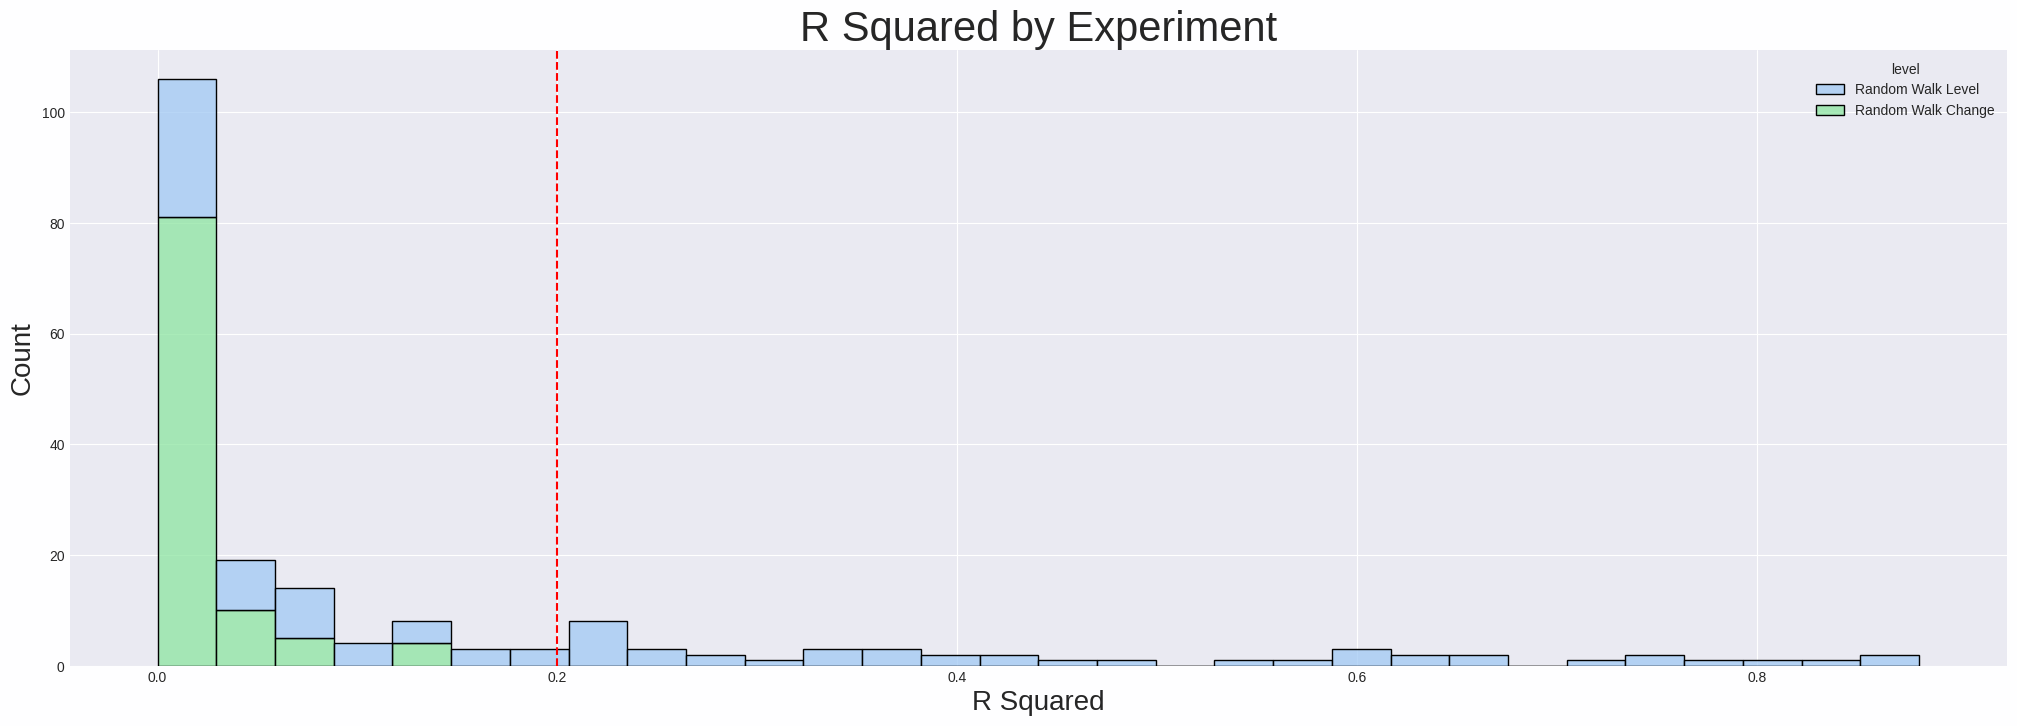

In [18]:
sns.histplot(df_combined, x='rsquared', hue='level',  multiple='stack', bins=30,palette=custom_palette)
plt.axvline(x=0.2, color='red', linestyle='--', linewidth=1.5, label='Critical Value (0.05)')

plt.title('R Squared by Experiment',size=30)
plt.xlabel('R Squared',size=20)
plt.ylabel('Count',size=20)

plt.show()

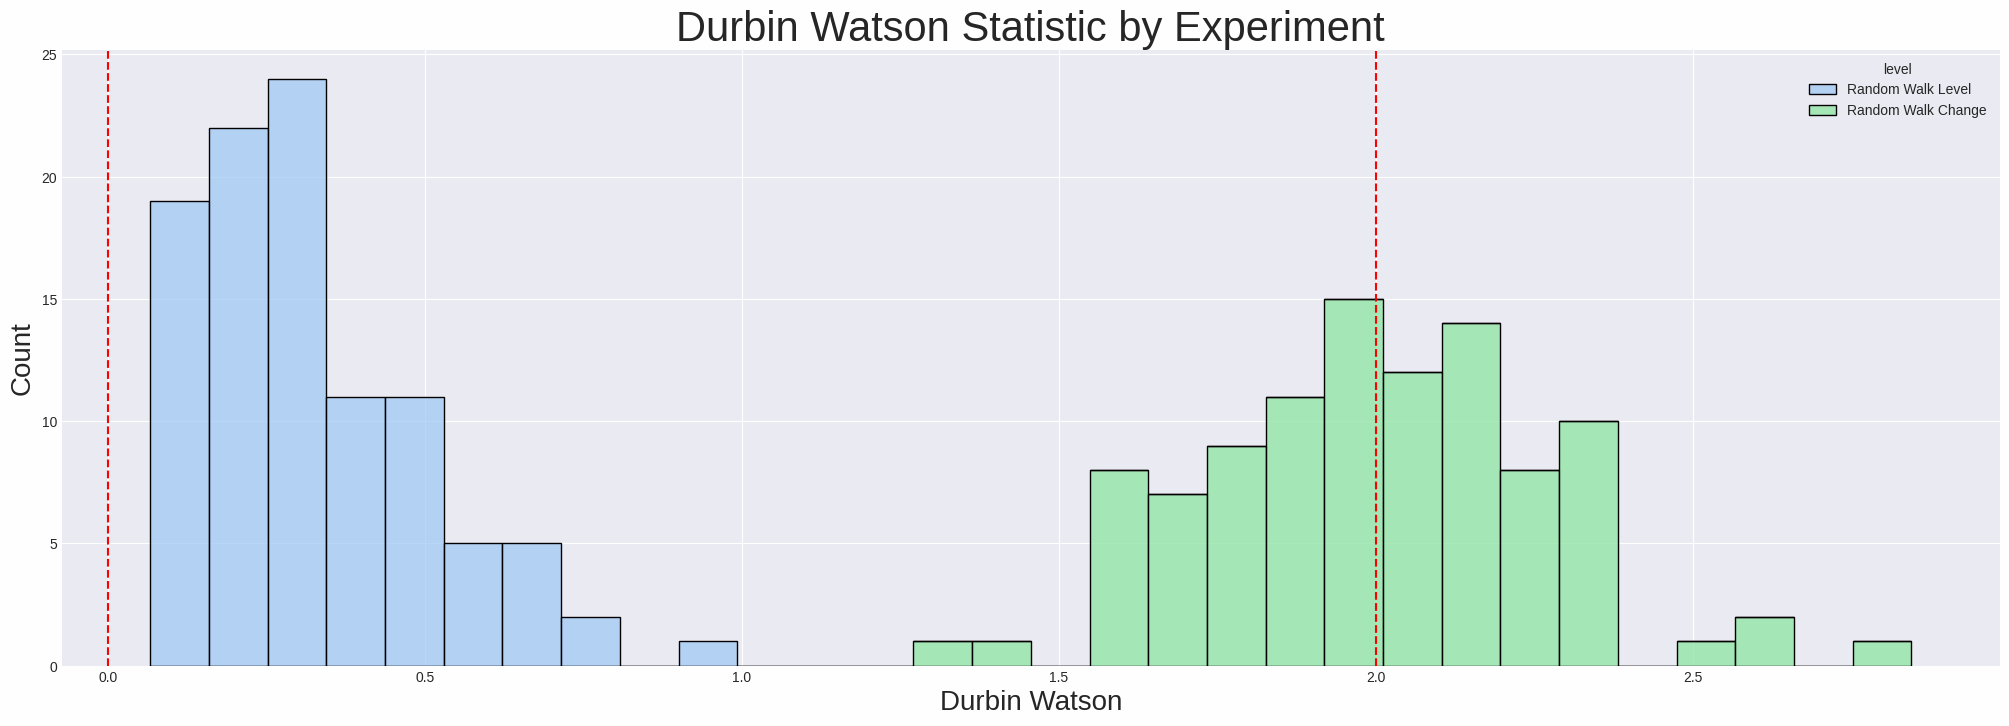

In [19]:
sns.histplot(df_combined, x='d_watson', hue='level',  multiple='stack', bins=30,palette=custom_palette)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='No Autocorrelation')
plt.axvline(x=2, color='red', linestyle='--', linewidth=1.5, label='Autocorrelation')

plt.title('Durbin Watson Statistic by Experiment',size=30)
plt.xlabel('Durbin Watson',size=20)
plt.ylabel('Count',size=20)

plt.show()